In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Linear Regression Model

In [3]:
class LinearRegression:
    def __init__(self):
        self.weights = np.random.randn(2)
        self.bias = np.random.randn()

    def predict(self, X):
        return X @ self.weights + self.bias

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

## Hypothesis Set:
y = w1*x1 + w2*x2 + b

In [4]:
x1 = np.arange(-1, 1.001, 0.02)
x2 = np.arange(-1, 1.001, 0.02)

X1, X2 = np.meshgrid(x1, x2)

grid = np.column_stack((X1.ravel(), X2.ravel()))

print("Number of grid points:", len(grid))
print("Grid shape:", grid.shape)

Number of grid points: 10201
Grid shape: (10201, 2)


In [5]:
model = LinearRegression()

print("Weights:", model.weights)
print("Bias:", model.bias)

Weights: [-0.53234449  0.11533235]
Bias: -0.13246447424430965


In [6]:
predictions = model.predict(grid)

Z = predictions.reshape(X1.shape)

print("Prediction shape:", predictions.shape)
print("Grid output shape:", Z.shape)

Prediction shape: (10201,)
Grid output shape: (101, 101)


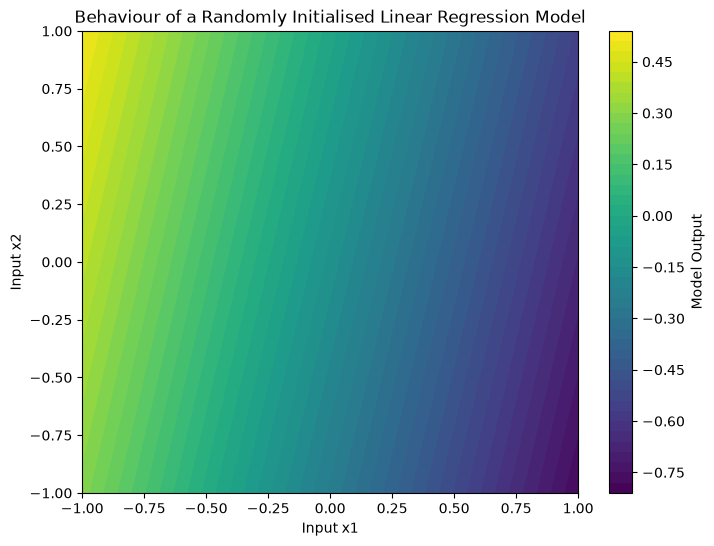

In [7]:
plt.figure(figsize=(8, 6))

plt.contourf(X1, X2, Z, levels=50)

plt.colorbar(label="Model Output")

plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.title("Behaviour of a Randomly Initialised Linear Regression Model")

plt.show()

In [8]:
print("Linear regression equation:")
print(
    f"y = {model.weights[0]:.4f} * x1 "
    f"+ {model.weights[1]:.4f} * x2 "
    f"+ {model.bias:.4f}"
)

Linear regression equation:
y = -0.5323 * x1 + 0.1153 * x2 + -0.1325


A synthetic dataset was created for the linear regression model. Each observation contains two input features, \(x_1\) and \(x_2\), and one continuous target value \(y\). The target is generated from a known linear relationship with added random noise.

In [9]:
np.random.seed(42)

X = np.random.uniform(-1, 1, (100, 2))

y = 3 * X[:, 0] + 2 * X[:, 1] + 1
y = y + np.random.normal(0, 0.2, 100)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (100, 2)
Target shape: (100,)


## Calculate Mean Squared Error (MSE)

In [10]:
predictions = model.predict(X)

loss = model.mse(y, predictions)

print("MSE:", loss)

MSE: 6.692882620399478


Generate Random Functions

In [11]:
models = []

for i in range(100):
    models.append(LinearRegression())

print("Number of models:", len(models))

Number of models: 100


Evaluate Random Functions

In [12]:
losses = []

for model in models:
    predictions = model.predict(X)
    loss = model.mse(y, predictions)
    losses.append(loss)

print("Best MSE:", min(losses))
print("Worst MSE:", max(losses))

best_index = np.argmin(losses)

best_model = models[best_index]

print("Best model weights:", best_model.weights)
print("Best model bias:", best_model.bias)
print("Best model MSE:", losses[best_index])

Best MSE: 1.9168428731091725
Worst MSE: 19.29305578974942
Best model weights: [2.06074792 1.75534084]
Best model bias: -0.2489641484790735
Best model MSE: 1.9168428731091725


Comparing performance of the random functions

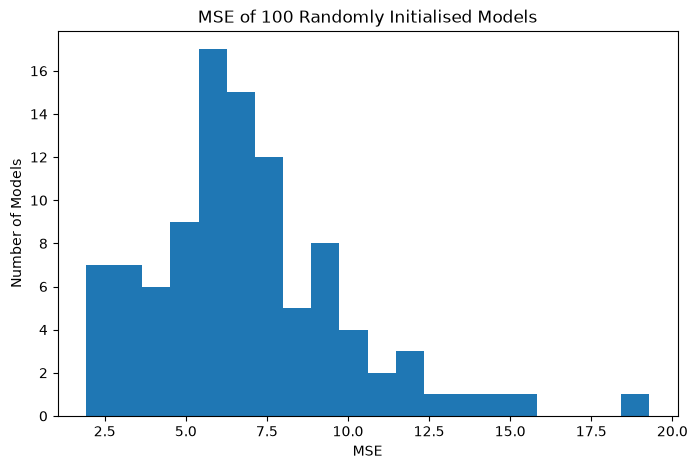

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(losses, bins=20)

plt.xlabel("MSE")
plt.ylabel("Number of Models")
plt.title("MSE of 100 Randomly Initialised Models")

plt.show()

Prediction Matrix

In [14]:
prediction_matrix = []

for model in models:
    predictions = model.predict(X)
    prediction_matrix.append(predictions)

prediction_matrix = np.array(prediction_matrix)

print("Prediction matrix shape:", prediction_matrix.shape)

Prediction matrix shape: (100, 100)
